In [3]:
import os
import datetime
import numpy as np
import pandas as pd
from functools import partial

# Model
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Seasonal Decompose
from statsmodels.tsa.seasonal import STL

# Optimization
import optuna

# Evaluation
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

# Data Loading

In [12]:
stock = pd.read_csv('../data/aapl_stock_price.csv', index_col=[0], parse_dates=[0])

# Data Preparation

In [6]:
def train_test_split(data, split_date):
    train = data[data.index < split_date]
    test = data[data.index >= split_date]
    return train, test

In [4]:
def seasonalDecompose(y, period, is_plot=True):
    stl = STL(y, period=period)  # Mulai dengan dugaan
    result = stl.fit()
    if is_plot:
        fig = result.plot() 
        fig.set_size_inches(13, 6)
        for axes in fig.axes:
            axes.grid(True)
        plt.show()
    return result

In [5]:
def feature_engineering(data, label=None):
    """
    Creates time series features
    """
    sdcompose_result = seasonalDecompose(data, period=252, is_plot=False)
    df = pd.concat(
        [data, 
         sdcompose_result.trend,
         sdcompose_result.seasonal,
         sdcompose_result.resid
        ], axis=1)
    df['lag'] = df[df.columns[0]].diff()
    df['ma'] = df[df.columns[0]].rolling(window=2).mean()
    df = df.fillna(0)
    df['date'] = df.index
    df['hour'] = df['date'].dt.hour
    df['dayofweek'] = df['date'].dt.dayofweek
    df['quarter'] = df['date'].dt.quarter
    df['month'] = df['date'].dt.month
    df['year'] = df['date'].dt.year
    df['dayofyear'] = df['date'].dt.dayofyear
    df['dayofmonth'] = df['date'].dt.day
    
    X = df[[col for col in df.columns if (col != label) & (col != 'date')]]
    if label:
        y = df[label]
        return X, y
    return X

In [13]:
# Define split date
start_date = stock.index[0]
split_index = round(len(stock) * 0.9)
split_date = stock.index[split_index] 

X_train, X_test = train_test_split(stock["Close"], split_date)

X_train, y_train = feature_engineering(X_train, "Close")
X_test, y_test = feature_engineering(X_test, "Close")

# Modelling

In [8]:
def train_eval_ml_model(model, X_train, X_test, y_train, y_test):
    """
    
    """
    # Train the input
    model.fit(X_train, y_train)
    # Predict
    y_pred = model.predict(X_test)
    # Eval
    rmse = root_mean_squared_error(y_test, y_pred)
    return rmse

def optuna_search(objective, n_trials, direction):
    """
    
    """
    # Create study
    study = optuna.create_study(direction=direction)
    study.optimize(objective, n_trials=n_trials)

    # Display the best trial, value, and params
    print("Best trial:")
    trial = study.best_trial
    print(f"  Value: {trial.value}")
    print("  Params: ")
    for key, value in trial.params.items():
        print(f"    {key}: {value}")
    
    return trial.params

def xgb_objective(trial, X_train, X_test, y_train, y_test):
    """
    
    """
    n_estimators = trial.suggest_int('n_estimators', 100, 350)
    max_depth = trial.suggest_int('max_depth', 3, 10)
    learning_rate = trial.suggest_loguniform('learning_rate', 0.001, 0.1)
    min_child_weight = trial.suggest_int('min_child_weight', 1, 10)
    subsample = trial.suggest_float('subsample', 0.5, 1.0)
    colsample_bytree = trial.suggest_float('colsample_bytree', 0.5, 1.0)
    reg_alpha = trial.suggest_loguniform('reg_alpha', 1e-5, 10.0)
    reg_lambda = trial.suggest_loguniform('reg_lambda', 1e-5, 10.0)
    
    model = XGBRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate=learning_rate,
        min_child_weight=min_child_weight,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        reg_alpha=reg_alpha,
        reg_lambda=reg_lambda,
        random_state=42,
        objective='reg:squarederror'
    )
    
    rmse = train_eval_ml_model(model, X_train, X_test, y_train, y_test)
    
    return rmse

def rf_objective(trial, X_train, X_test, y_train, y_test):
    """
    
    """
    n_estimators = trial.suggest_int('n_estimators', 100, 350)
    max_depth = trial.suggest_int('max_depth', 10, 32)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)
    bootstrap = trial.suggest_categorical('bootstrap', [True, False])
    
    model = RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        bootstrap=bootstrap
    )
    
    rmse =train_eval_ml_model(model, X_train, X_test, y_train, y_test)
    
    return rmse

## Perform Hyperparameter Search

### XGBoost

In [14]:
# Hyperparameter tuning with xgboost
xgb_partial = partial(xgb_objective, X_train=X_train, X_test=X_test, y_train=y_train, y_test=y_test)
xgb_best_params = optuna_search(xgb_partial, 100, "minimize")

[I 2025-04-21 10:42:18,798] A new study created in memory with name: no-name-bdfaca27-5ca1-4cc3-9fd3-e875498eca62
C:\Users\fadhil\AppData\Local\Temp\ipykernel_23412\1313802648.py:37: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  learning_rate = trial.suggest_loguniform('learning_rate', 0.001, 0.1)
C:\Users\fadhil\AppData\Local\Temp\ipykernel_23412\1313802648.py:41: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  reg_alpha = trial.suggest_loguniform('reg_alpha', 1e-5, 10.0)
C:\Users\fadhil\AppData\Local\Temp\ipykernel_23412\1313802648.py:42: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optun

Best trial:
  Value: 26.88605836464077
  Params: 
    n_estimators: 337
    max_depth: 3
    learning_rate: 0.09383456438297946
    min_child_weight: 8
    subsample: 0.8393523800338795
    colsample_bytree: 0.6337852081795458
    reg_alpha: 0.0001379058421308067
    reg_lambda: 0.0007017123698971091


In [16]:
xgb_model = XGBRegressor(**xgb_best_params, random_state=42, objective='reg:squarederror')
xgb_model.fit(X_train, y_train)
y_predict = xgb_model.predict(X_test)
rmse = root_mean_squared_error(y_test, y_predict)
mae = mean_absolute_error(y_test, y_predict)
mape = mean_absolute_percentage_error(y_test, y_predict)

print(f"RMSE : {rmse} | MAE : {mae}, | MAPE : {mape}")

RMSE : 26.88605836464077 | MAE : 20.43999233924353, | MAPE : 0.090025994295094


In [20]:
close_predict_series = pd.Series(y_predict, index=y_test.index, name="Predict")
concate_results = pd.concat([y_test, close_predict_series], axis=1)
close_all = pd.concat([y_train, concate_results], sort=False)

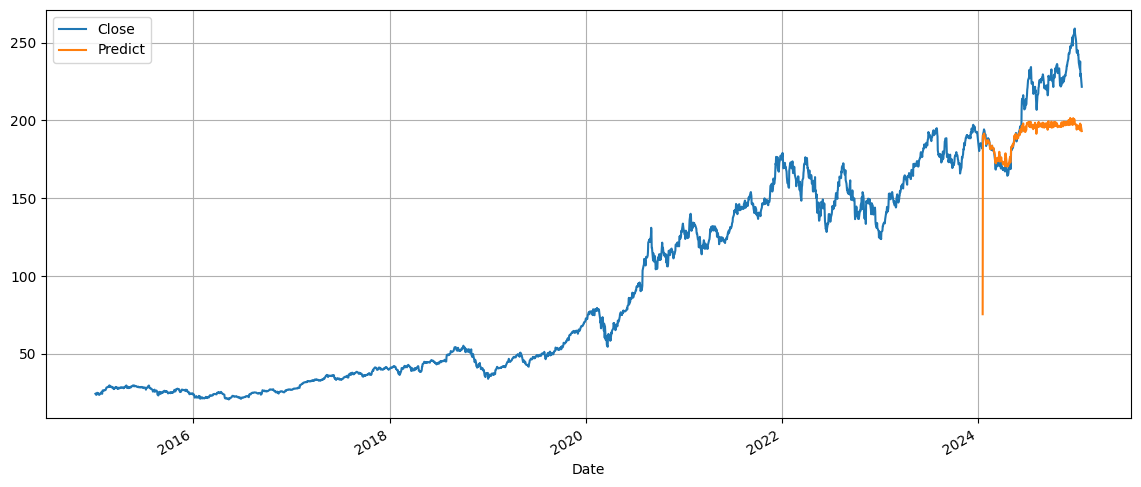

In [22]:
close_all[['Close', 'Predict']].plot(figsize=(14,6))
plt.grid(True)

### Random Forest

In [23]:
# Hyperparameter tuning with xgboost
rf_partial = partial(rf_objective, X_train=X_train, X_test=X_test, y_train=y_train, y_test=y_test)
rf_best_params = optuna_search(rf_partial, 100, "minimize")

[I 2025-04-21 10:52:16,344] A new study created in memory with name: no-name-7390a651-08f6-45f0-9412-0d30f0d9decd
[I 2025-04-21 10:52:21,042] Trial 0 finished with value: 28.375488877419524 and parameters: {'n_estimators': 335, 'max_depth': 28, 'min_samples_split': 8, 'min_samples_leaf': 1, 'bootstrap': False}. Best is trial 0 with value: 28.375488877419524.
[I 2025-04-21 10:52:24,693] Trial 1 finished with value: 28.371521707007485 and parameters: {'n_estimators': 294, 'max_depth': 26, 'min_samples_split': 8, 'min_samples_leaf': 4, 'bootstrap': False}. Best is trial 1 with value: 28.371521707007485.
[I 2025-04-21 10:52:29,120] Trial 2 finished with value: 28.368957610369524 and parameters: {'n_estimators': 336, 'max_depth': 22, 'min_samples_split': 7, 'min_samples_leaf': 3, 'bootstrap': False}. Best is trial 2 with value: 28.368957610369524.
[I 2025-04-21 10:52:31,074] Trial 3 finished with value: 28.945439445622817 and parameters: {'n_estimators': 173, 'max_depth': 15, 'min_samples_s

Best trial:
  Value: 27.83492006782024
  Params: 
    n_estimators: 180
    max_depth: 10
    min_samples_split: 5
    min_samples_leaf: 1
    bootstrap: True


In [24]:
rf_model = RandomForestRegressor(**rf_best_params)
rf_model.fit(X_train, y_train)
y_predict = rf_model.predict(X_test)
rmse = root_mean_squared_error(y_test, y_predict)
mae = mean_absolute_error(y_test, y_predict)
mape = mean_absolute_percentage_error(y_test, y_predict)

print(f"RMSE : {rmse} | MAE : {mae}, | MAPE : {mape}")

RMSE : 28.08648793527671 | MAE : 20.218558194801922, | MAPE : 0.08816093134251439


In [25]:
close_predict_series = pd.Series(y_predict, index=y_test.index, name="Predict")
concate_results = pd.concat([y_test, close_predict_series], axis=1)
close_all = pd.concat([y_train, concate_results], sort=False)

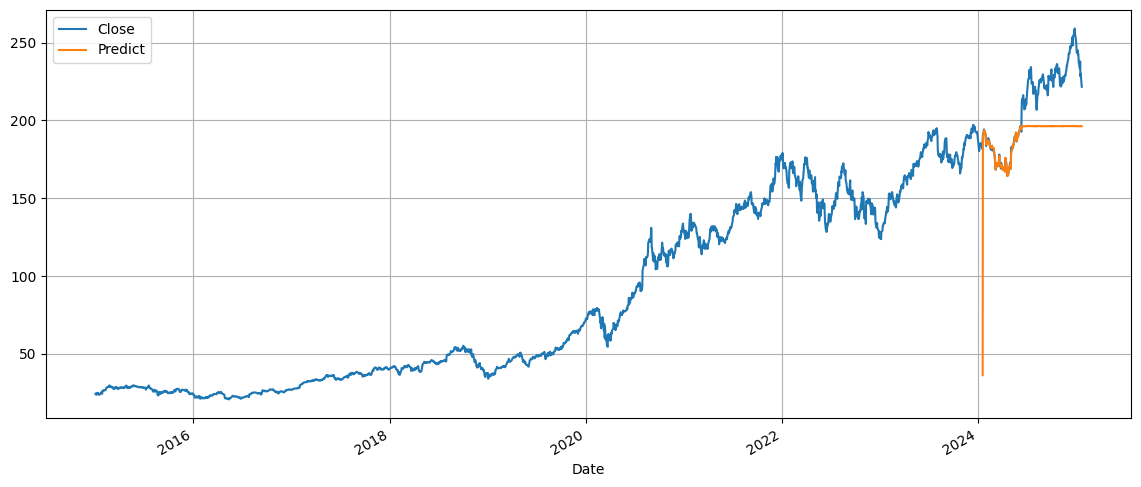

In [26]:
close_all[['Close', 'Predict']].plot(figsize=(14,6))
plt.grid(True)